In [2]:
!pip install nbformat

#Outlier Detection & Treatment + Linear Regression on Diamonds Dataset

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

df = sns.load_dataset('diamonds')
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [5]:
# diamonds has categorical columns - need to encode first
df = pd.get_dummies(df, columns=['cut','color','clarity'], drop_first=True)
df.head()

,carat,depth,table,price,x,y,z,cut_Premium,cut_Very Good,cut_Good,...,color_H,color_I,color_J,clarity_VVS1,clarity_VVS2,clarity_VS1,clarity_VS2,clarity_SI1,clarity_SI2,clarity_I1
0,0.23,61.5,55.0,326,3.95,3.98,2.43,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,0.21,59.8,61.0,326,3.89,3.84,2.31,True,False,False,...,False,False,False,False,False,False,False,True,False,False
2,0.23,56.9,65.0,327,4.05,4.07,2.31,False,False,True,...,False,False,False,False,False,True,False,False,False,False
3,0.29,62.4,58.0,334,4.20,4.23,2.63,True,False,False,...,False,True,False,False,False,False,True,False,False,False
4,0.31,63.3,58.0,335,4.34,4.35,2.75,False,False,True,...,False,False,True,False,False,False,False,False,True,False


In [6]:
df['price'].describe()

,price
count,53940.000000
mean,3932.799722
std,3989.439738
min,326.000000
25%,950.000000
50%,2401.000000
75%,5324.250000
max,18823.000000


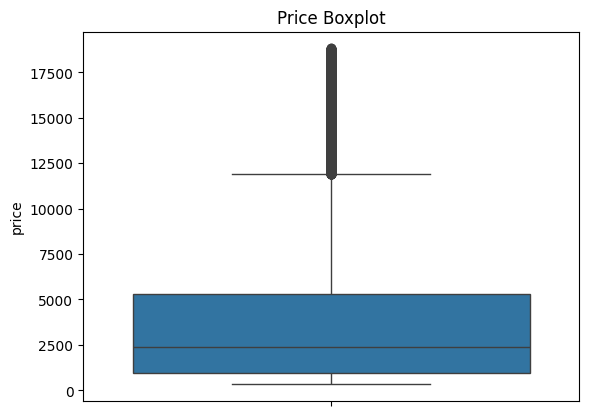

In [7]:
sns.boxplot(df['price'])
plt.title('Price Boxplot')
plt.show()

##Finding IQR & Outliers


In [8]:
percentile25 = df['price'].quantile(0.25)
percentile75 = df['price'].quantile(0.75)

iqr = percentile75 - percentile25

upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

print("25th Percentile :", percentile25)
print("75th Percentile :", percentile75)
print("IQR             :", iqr)
print("Upper Limit     :", upper_limit)
print("Lower Limit     :", lower_limit)

25th Percentile : 950.0
75th Percentile : 5324.25
IQR             : 4374.25
Upper Limit     : 11885.625
Lower Limit     : -5611.375


In [9]:
outliers = df[(df['price'] > upper_limit) | (df['price'] < lower_limit)]
print("Total Outliers:", outliers.shape[0])
outliers.head()


Total Outliers: 3540


,carat,depth,table,price,x,y,z,cut_Premium,cut_Very Good,cut_Good,...,color_H,color_I,color_J,clarity_VVS1,clarity_VVS2,clarity_VS1,clarity_VS2,clarity_SI1,clarity_SI2,clarity_I1
23820,1.17,62.1,57.0,11886,6.82,6.73,4.21,False,False,False,...,False,False,False,True,False,False,False,False,False,False
23821,2.08,62.0,56.0,11886,8.21,8.10,5.06,False,False,False,...,False,True,False,False,False,False,False,False,True,False
23822,1.70,62.2,58.0,11888,7.65,7.60,4.74,True,False,False,...,False,True,False,False,False,False,True,False,False,False
23823,1.09,61.6,55.0,11888,6.59,6.65,4.08,False,False,False,...,False,False,False,False,False,False,False,False,False,False
23824,1.68,60.4,55.0,11888,7.79,7.70,4.68,False,False,False,...,False,False,False,False,False,False,False,False,True,False



## Linear Regression — BEFORE Outlier Treatment

In [10]:
X_before = df.drop('price', axis=1)
y_before = df['price']

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_before, y_before, test_size=0.2, random_state=42
)

model_before = LinearRegression()
model_before.fit(X_train_b, y_train_b)
y_pred_b = model_before.predict(X_test_b)

r2_before    = r2_score(y_test_b, y_pred_b)
mse_before   = mean_squared_error(y_test_b, y_pred_b)
rmse_before  = np.sqrt(mse_before)
mae_before   = mean_absolute_error(y_test_b, y_pred_b)

print("===== BEFORE Outlier Treatment =====")
print(f"R² Score : {r2_before:.4f}")
print(f"MSE      : {mse_before:.2f}")
print(f"RMSE     : {rmse_before:.2f}")
print(f"MAE      : {mae_before:.2f}")

===== BEFORE Outlier Treatment =====
R² Score : 0.9189
MSE      : 1288705.48
RMSE     : 1135.21
MAE      : 737.15


##Trimming

In [13]:
df_trimmed = df[df['price'] < upper_limit]
print("Shape after Trimming:", df_trimmed.shape)

Shape after Trimming: (50400, 24)


In [14]:
X_trim = df_trimmed.drop('price', axis=1)
y_trim = df_trimmed['price']

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_trim, y_trim, test_size=0.2, random_state=42
)

model_trim = LinearRegression()
model_trim.fit(X_train_t, y_train_t)
y_pred_t = model_trim.predict(X_test_t)

r2_trim   = r2_score(y_test_t, y_pred_t)
mse_trim  = mean_squared_error(y_test_t, y_pred_t)
rmse_trim = np.sqrt(mse_trim)
mae_trim  = mean_absolute_error(y_test_t, y_pred_t)

print("===== AFTER Trimming =====")
print(f"R² Score : {r2_trim:.4f}")
print(f"MSE      : {mse_trim:.2f}")
print(f"RMSE     : {rmse_trim:.2f}")
print(f"MAE      : {mae_trim:.2f}")


===== AFTER Trimming =====
R² Score : 0.9176
MSE      : 607853.16
RMSE     : 779.65
MAE      : 533.07


##Capping

In [15]:
df_cap = df.copy()
df_cap['price'] = np.where(
    df_cap['price'] > upper_limit,
    upper_limit,
    np.where(
        df_cap['price'] < lower_limit,
        lower_limit,
        df_cap['price']
    )
)
print("Shape after Capping:", df_cap.shape)

Shape after Capping: (53940, 24)


In [16]:
X_cap = df_cap.drop('price', axis=1)
y_cap = df_cap['price']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cap, y_cap, test_size=0.2, random_state=42
)

model_cap = LinearRegression()
model_cap.fit(X_train_c, y_train_c)
y_pred_c = model_cap.predict(X_test_c)

r2_cap   = r2_score(y_test_c, y_pred_c)
mse_cap  = mean_squared_error(y_test_c, y_pred_c)
rmse_cap = np.sqrt(mse_cap)
mae_cap  = mean_absolute_error(y_test_c, y_pred_c)

print("===== AFTER Capping =====")
print(f"R² Score : {r2_cap:.4f}")
print(f"MSE      : {mse_cap:.2f}")
print(f"RMSE     : {rmse_cap:.2f}")
print(f"MAE      : {mae_cap:.2f}")


===== AFTER Capping =====
R² Score : 0.9296
MSE      : 824926.76
RMSE     : 908.25
MAE      : 646.53


In [18]:
comparison = pd.DataFrame({
    'Method'   : ['Before Treatment', 'After Trimming', 'After Capping'],
    'R² Score' : [r2_before, r2_trim, r2_cap],
    'MSE'      : [mse_before, mse_trim, mse_cap],
    'RMSE'     : [rmse_before, rmse_trim, rmse_cap],
    'MAE'      : [mae_before, mae_trim, mae_cap]
})

comparison

,Method,R² Score,MSE,RMSE,MAE
0,Before Treatment,0.918933,1.288705e+06,1135.211645,737.151367
1,After Trimming,0.917583,6.078532e+05,779.649385,533.069149
2,After Capping,0.929569,8.249268e+05,908.254788,646.525443


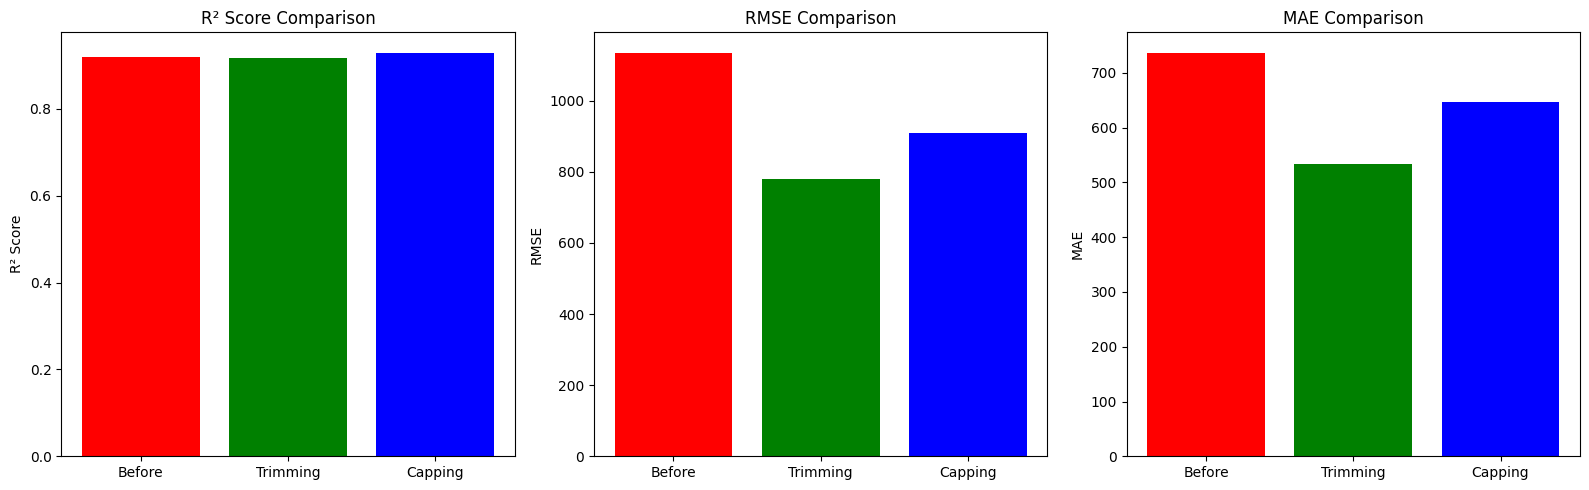

In [17]:
plt.figure(figsize=(16,5))

plt.subplot(1,3,1)
plt.bar(['Before','Trimming','Capping'],
        [r2_before, r2_trim, r2_cap],
        color=['red','green','blue'])
plt.title('R² Score Comparison')
plt.ylabel('R² Score')

plt.subplot(1,3,2)
plt.bar(['Before','Trimming','Capping'],
        [rmse_before, rmse_trim, rmse_cap],
        color=['red','green','blue'])
plt.title('RMSE Comparison')
plt.ylabel('RMSE')

plt.subplot(1,3,3)
plt.bar(['Before','Trimming','Capping'],
        [mae_before, mae_trim, mae_cap],
        color=['red','green','blue'])
plt.title('MAE Comparison')
plt.ylabel('MAE')

plt.tight_layout()
plt.show()